In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
# #Importing Model Data
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc', decode_timedelta=True) #***
parcel1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc', decode_timedelta=True) #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc', decode_timedelta=True) #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc', decode_timedelta=True) #***
# res='1km'; t_res='1min_95nz'; Np_str='50e6'

# # dx = 250km; Np = 50M;
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_250m_1min_50M.nc', decode_timedelta=True) #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_250m_1min_50M.nc', decode_timedelta=True) #***
# res='250m'; t_res='1min'; Np_str='50e6'

In [2]:
file_path = dir2 + 'Variable_Calculation/OUTPUT/' + f'theta_e_{res}_{t_res}.h5'
th_e_ds1 = xr.open_dataset(file_path, phony_dims='sort',engine='h5netcdf')  # or engine='netcdf4'
th_e_ds1 = th_e_ds1.rename({
    'phony_dim_0': 'time',
    'phony_dim_1': 'zh',
    'phony_dim_2': 'yh',
    'phony_dim_3': 'xh'
})

In [ ]:
t=100
w=data1['winterp'].isel(time=t).data
qc=data1['qc'].isel(time=t).data
qi=data1['qi'].isel(time=t).data
RH = th_e_ds1['RH'].isel(time=t).data
RH_ice = th_e_ds1['RH_ice'].isel(time=t).data

In [123]:
# w_thresh2 = 0.5; qc_thresh = 1e-6; qi_thresh = 1e-6
# cond1=(w>=w_thresh2); cond2=(qc>=qc_thresh); cond3=(qi>=qi_thresh)
# RH_cloudy = RH[cond2]
# RH_ice_cloudy = RH_ice[cond3]

# fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# # Left subplot: RH_cloudy
# axs[0].scatter(RH_cloudy, np.arange(len(RH_cloudy)), color='blue')
# axs[0].set_title('RH Cloudy Regions')
# axs[0].set_xlabel('RH')
# axs[0].set_ylabel('Index')

# # Right subplot: RH_ice_cloudy
# axs[1].scatter(RH_ice_cloudy, np.arange(len(RH_ice_cloudy)), color='red')
# axs[1].set_title('RH Ice in Icy Regions (qi >= 1e-6)')
# axs[1].set_xlabel('RH Ice')
# axs[1].set_ylabel('Index')

# plt.tight_layout()
# plt.show()


In [124]:
# # Conditions
# w_thresh2 = 0.5
# qc_thresh = 1e-6
# qi_thresh = 1e-6

# cond1 = (w >= w_thresh2)
# cond2 = (qc >= qc_thresh)
# cond3 = (qi >= qi_thresh)

# # Initialize with NaNs (same shape as RH)
# RH_cloudy_masked = np.full_like(RH, np.nan, dtype=float)
# RH_ice_cloudy_masked = np.full_like(RH_ice, np.nan, dtype=float)

# # Assign values only where conditions hold
# RH_cloudy_masked[cond2] = RH[cond2]
# RH_ice_cloudy_masked[cond3] = RH_ice[cond3]

# # Calculate horizontal mean ignoring NaNs
# # Assuming horizontal dimension is last axis (-1)
# mean_RH_cloudy = np.nanmean(RH_cloudy_masked, axis=-1)
# mean_RH_ice_cloudy = np.nanmean(RH_ice_cloudy_masked, axis=-1)

# mean_RH_cloudy_1d = np.nanmean(RH_cloudy_masked, axis=(-2, -1))
# mean_RH_ice_cloudy_1d = np.nanmean(RH_ice_cloudy_masked, axis=(-2, -1))

# import matplotlib.pyplot as plt

# fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# # Top-left subplot: mean_RH_cloudy contourf
# cf1 = axs[0, 0].contourf(data1['yh'], data1['zh'], mean_RH_cloudy, cmap='viridis')
# fig.colorbar(cf1, ax=axs[0, 0])
# axs[0, 0].set_title('Mean RH Cloudy')
# axs[0, 0].set_xlabel('yh')
# axs[0, 0].set_ylabel('zh')

# # Top-right subplot: mean_RH_ice_cloudy contourf
# cf2 = axs[0, 1].contourf(data1['yh'], data1['zh'], mean_RH_ice_cloudy, cmap='plasma')
# fig.colorbar(cf2, ax=axs[0, 1])
# axs[0, 1].set_title('Mean RH Icy')
# axs[0, 1].set_xlabel('yh')
# axs[0, 1].set_ylabel('zh')

# # Bottom-left subplot: line plot of 2D horizontally averaged RH_cloudy
# axs[1, 0].plot(mean_RH_cloudy_1d, data1['zh'], label='RH Cloudy', color='blue')
# axs[1, 0].set_title('Horizontally Averaged RH Cloudy')
# axs[1, 0].set_xlabel('RH')
# axs[1, 0].set_ylabel('zh')
# axs[1, 0].legend()
# axs[1,0].set_ylim(bottom=0)
# axs[1,0].set_ylim(bottom=0,top=data1['zf'].max())

# # Bottom-right subplot: line plot of 2D horizontally averaged RH_ice_cloudy
# axs[1, 1].plot(mean_RH_ice_cloudy_1d, data1['zh'], label='RH Icy', color='red')
# axs[1, 1].set_title('Horizontally Averaged RH Ice Cloudy')
# axs[1, 1].set_xlabel('RH Ice')
# axs[1, 1].set_ylabel('zh')
# axs[1, 1].legend()
# axs[1,1].set_ylim(bottom=0,top=data1['zf'].max())

# plt.tight_layout()
# plt.show()


/tmp/ipykernel_404829/1004034383.py:20: RuntimeWarning: Mean of empty slice
  mean_RH_cloudy = np.nanmean(RH_cloudy_masked, axis=-1)
/tmp/ipykernel_404829/1004034383.py:21: RuntimeWarning: Mean of empty slice
  mean_RH_ice_cloudy = np.nanmean(RH_ice_cloudy_masked, axis=-1)
/tmp/ipykernel_404829/1004034383.py:23: RuntimeWarning: Mean of empty slice
  mean_RH_cloudy_1d = np.nanmean(RH_cloudy_masked, axis=(-2, -1))
/tmp/ipykernel_404829/1004034383.py:24: RuntimeWarning: Mean of empty slice
  mean_RH_ice_cloudy_1d = np.nanmean(RH_ice_cloudy_masked, axis=(-2, -1))


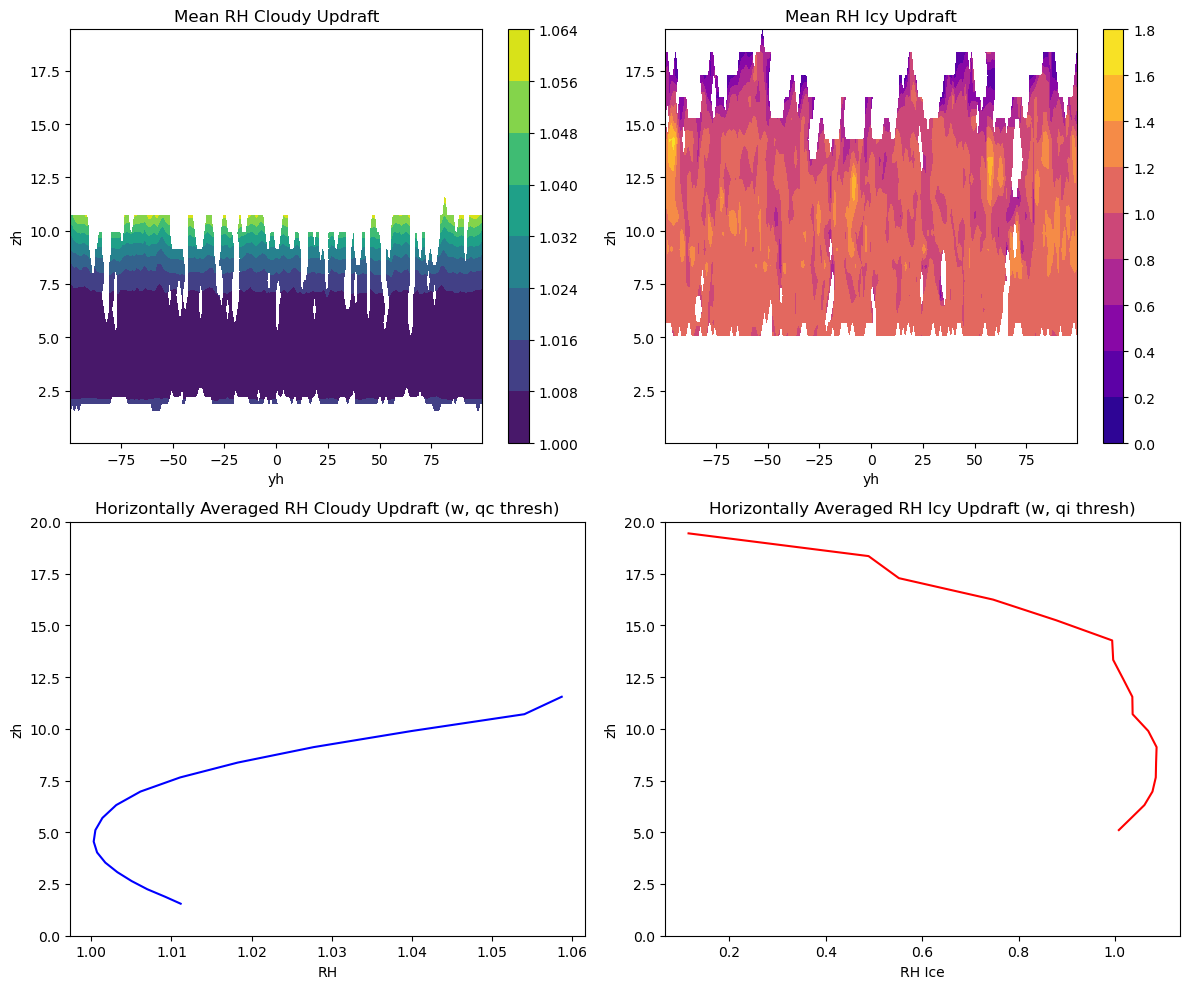

In [125]:
# Conditions
w_thresh2 = 0.5
qc_thresh = 1e-6
qi_thresh = 1e-6

cond1 = (w >= w_thresh2)
cond2 = (qc >= qc_thresh)
cond3 = (qi >= qi_thresh)

# Initialize with NaNs (same shape as RH)
RH_cloudy_masked = np.full_like(RH, np.nan, dtype=float)
RH_ice_cloudy_masked = np.full_like(RH_ice, np.nan, dtype=float)

# Assign values only where conditions hold
RH_cloudy_masked[cond1 & cond2] = RH[cond1 & cond2]
RH_ice_cloudy_masked[cond1 & cond3] = RH_ice[cond1 & cond3]

# Calculate horizontal mean ignoring NaNs
# Assuming horizontal dimension is last axis (-1)
mean_RH_cloudy = np.nanmean(RH_cloudy_masked, axis=-1)
mean_RH_ice_cloudy = np.nanmean(RH_ice_cloudy_masked, axis=-1)

mean_RH_cloudy_1d = np.nanmean(RH_cloudy_masked, axis=(-2, -1))
mean_RH_ice_cloudy_1d = np.nanmean(RH_ice_cloudy_masked, axis=(-2, -1))

import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Top-left subplot: mean_RH_cloudy contourf
cf1 = axs[0, 0].contourf(data1['yh'], data1['zh'], mean_RH_cloudy, cmap='viridis')
fig.colorbar(cf1, ax=axs[0, 0])
axs[0, 0].set_title('Mean RH Cloudy Updraft')
axs[0, 0].set_xlabel('yh')
axs[0, 0].set_ylabel('zh')

# Top-right subplot: mean_RH_ice_cloudy contourf
cf2 = axs[0, 1].contourf(data1['yh'], data1['zh'], mean_RH_ice_cloudy, cmap='plasma')
fig.colorbar(cf2, ax=axs[0, 1])
axs[0, 1].set_title('Mean RH Icy Updraft')
axs[0, 1].set_xlabel('yh')
axs[0, 1].set_ylabel('zh')

# Bottom-left subplot: line plot of 2D horizontally averaged RH_cloudy
axs[1, 0].plot(mean_RH_cloudy_1d, data1['zh'], label='RH Cloudy', color='blue')
axs[1, 0].set_title('Horizontally Averaged RH Cloudy Updraft (w, qc thresh)')
axs[1, 0].set_xlabel('RH')
axs[1, 0].set_ylabel('zh')
# axs[1, 0].legend()
axs[1,0].set_ylim(bottom=0,top=data1['zf'].max())

# Bottom-right subplot: line plot of 2D horizontally averaged RH_ice_cloudy
axs[1, 1].plot(mean_RH_ice_cloudy_1d, data1['zh'], label='RH Ice Cloudy', color='red')
axs[1, 1].set_title('Horizontally Averaged RH Icy Updraft (w, qi thresh)')
axs[1, 1].set_xlabel('RH Ice')
axs[1, 1].set_ylabel('zh')
# axs[1, 1].legend()
axs[1,1].set_ylim(bottom=0,top=data1['zf'].max())

plt.tight_layout()
plt.show()


/tmp/ipykernel_404829/2583501567.py:21: RuntimeWarning: Mean of empty slice
  mean_RH_cloudy = np.nanmean(RH_cloudy_masked, axis=-1)
/tmp/ipykernel_404829/2583501567.py:22: RuntimeWarning: Mean of empty slice
  mean_RH_ice_cloudy = np.nanmean(RH_ice_cloudy_masked, axis=-1)
/tmp/ipykernel_404829/2583501567.py:24: RuntimeWarning: Mean of empty slice
  mean_RH_cloudy_1d = np.nanmean(RH_cloudy_masked, axis=(-2, -1))
/tmp/ipykernel_404829/2583501567.py:25: RuntimeWarning: Mean of empty slice
  mean_RH_ice_cloudy_1d = np.nanmean(RH_ice_cloudy_masked, axis=(-2, -1))


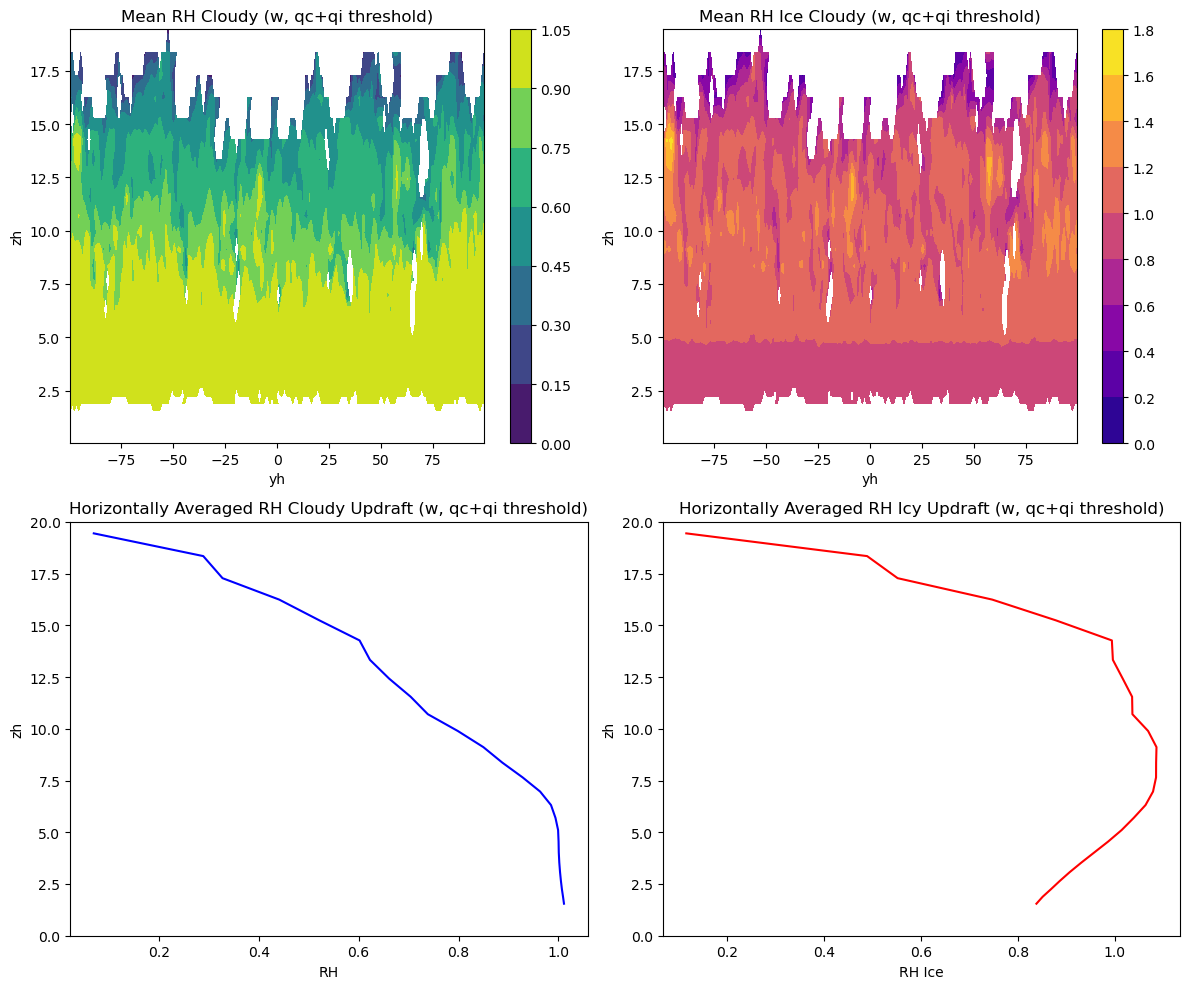

In [127]:
# Conditions
w_thresh2 = 0.5
qc_thresh = 1e-6
qi_thresh = 1e-6

cond1 = (w >= w_thresh2)
cond2 = (qc >= qc_thresh)
cond3 = (qi >= qi_thresh)
cond4 = (qc+qi >= qc_thresh)

# Initialize with NaNs (same shape as RH)
RH_cloudy_masked = np.full_like(RH, np.nan, dtype=float)
RH_ice_cloudy_masked = np.full_like(RH_ice, np.nan, dtype=float)

# Assign values only where conditions hold
RH_cloudy_masked[cond1 & cond4] = RH[cond1 & cond4]
RH_ice_cloudy_masked[cond1 & cond4] = RH_ice[cond1 & cond4]

# Calculate horizontal mean ignoring NaNs
# Assuming horizontal dimension is last axis (-1)
mean_RH_cloudy = np.nanmean(RH_cloudy_masked, axis=-1)
mean_RH_ice_cloudy = np.nanmean(RH_ice_cloudy_masked, axis=-1)

mean_RH_cloudy_1d = np.nanmean(RH_cloudy_masked, axis=(-2, -1))
mean_RH_ice_cloudy_1d = np.nanmean(RH_ice_cloudy_masked, axis=(-2, -1))

import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Top-left subplot: mean_RH_cloudy contourf
cf1 = axs[0, 0].contourf(data1['yh'], data1['zh'], mean_RH_cloudy, cmap='viridis')
fig.colorbar(cf1, ax=axs[0, 0])
axs[0, 0].set_title('Mean RH Cloudy (w, qc+qi threshold)')
axs[0, 0].set_xlabel('yh')
axs[0, 0].set_ylabel('zh')

# Top-right subplot: mean_RH_ice_cloudy contourf
cf2 = axs[0, 1].contourf(data1['yh'], data1['zh'], mean_RH_ice_cloudy, cmap='plasma')
fig.colorbar(cf2, ax=axs[0, 1])
axs[0, 1].set_title('Mean RH Ice Cloudy (w, qc+qi threshold)')
axs[0, 1].set_xlabel('yh')
axs[0, 1].set_ylabel('zh')

# Bottom-left subplot: line plot of 2D horizontally averaged RH_cloudy
axs[1, 0].plot(mean_RH_cloudy_1d, data1['zh'], label='RH Cloudy', color='blue')
axs[1, 0].set_title('Horizontally Averaged RH Cloudy Updraft (w, qc+qi threshold)')
axs[1, 0].set_xlabel('RH')
axs[1, 0].set_ylabel('zh')
# axs[1, 0].legend()
axs[1,0].set_ylim(bottom=0,top=data1['zf'].max())

# Bottom-right subplot: line plot of 2D horizontally averaged RH_ice_cloudy
axs[1, 1].plot(mean_RH_ice_cloudy_1d, data1['zh'], label='RH Ice Cloudy', color='red')
axs[1, 1].set_title('Horizontally Averaged RH Icy Updraft (w, qc+qi threshold)')
axs[1, 1].set_xlabel('RH Ice')
axs[1, 1].set_ylabel('zh')
# axs[1, 1].legend()
axs[1,1].set_ylim(bottom=0,top=data1['zf'].max())

plt.tight_layout()
plt.show()


/tmp/ipykernel_404829/2906215331.py:20: RuntimeWarning: Mean of empty slice
  mean_qc_cloudy = np.nanmean(qc_cloudy_masked, axis=-1)
/tmp/ipykernel_404829/2906215331.py:21: RuntimeWarning: Mean of empty slice
  mean_qi_cloudy = np.nanmean(qi_cloudy_masked, axis=-1)
/tmp/ipykernel_404829/2906215331.py:23: RuntimeWarning: Mean of empty slice
  mean_qc_cloudy_1d = np.nanmean(qc_cloudy_masked, axis=(-2, -1))
/tmp/ipykernel_404829/2906215331.py:24: RuntimeWarning: Mean of empty slice
  mean_qi_cloudy_1d = np.nanmean(qi_cloudy_masked, axis=(-2, -1))


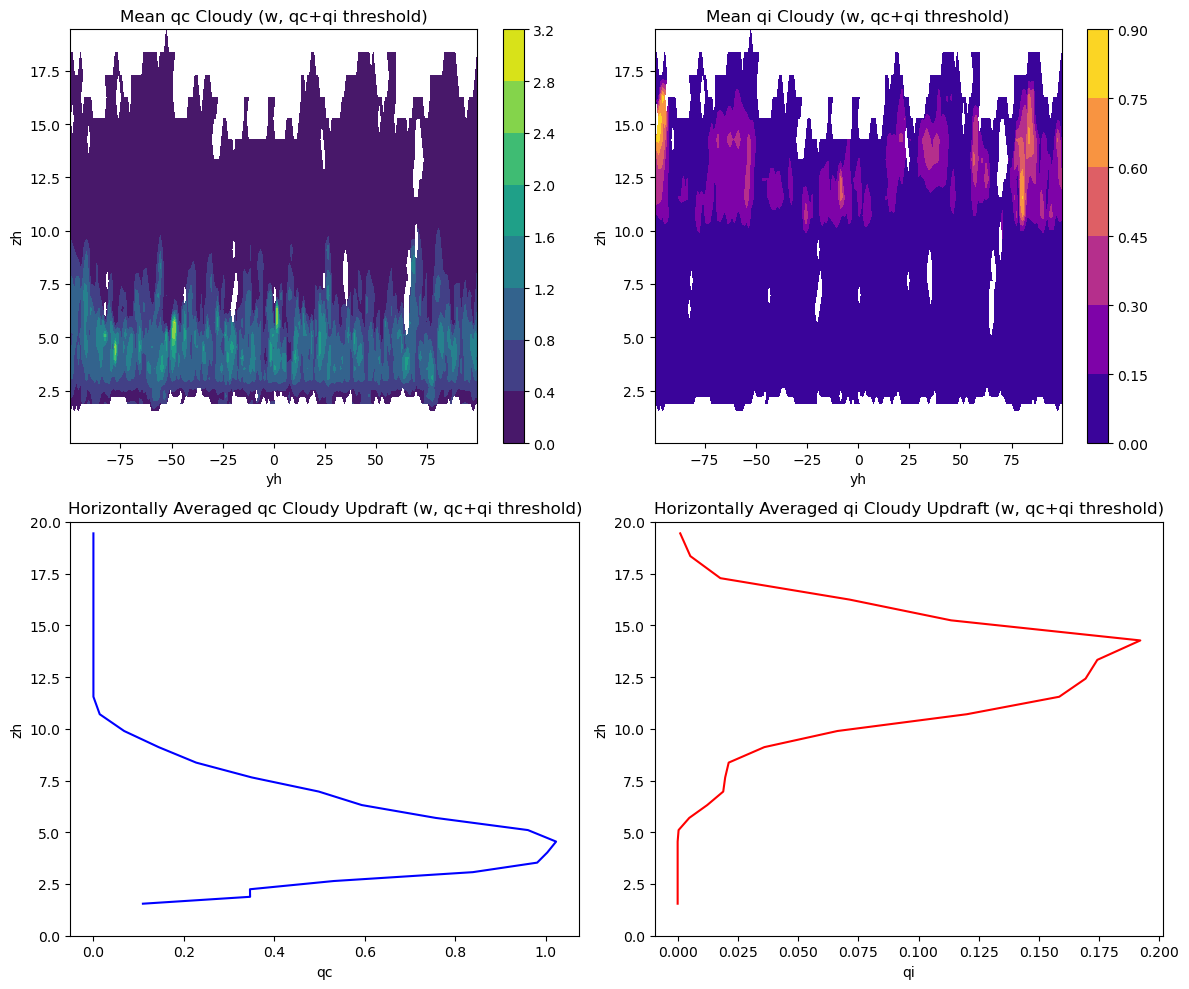

In [129]:
w_thresh2 = 0.5
qc_thresh = 1e-6
qi_thresh = 1e-6

cond1 = (w >= w_thresh2)
cond2 = (qc >= qc_thresh)
cond3 = (qi >= qi_thresh)
cond4 = (qc+qi >= qc_thresh)

# Initialize with NaNs (same shape as RH)
qc_cloudy_masked = np.full_like(qc, np.nan, dtype=float)
qi_cloudy_masked = np.full_like(qi, np.nan, dtype=float)

# Assign values only where conditions hold
qc_cloudy_masked[cond1 & cond4] = qc[cond1 & cond4]
qi_cloudy_masked[cond1 & cond4] = qi[cond1 & cond4]

# Calculate horizontal mean ignoring NaNs
# Assuming horizontal dimension is last axis (-1)
mean_qc_cloudy = np.nanmean(qc_cloudy_masked, axis=-1)
mean_qi_cloudy = np.nanmean(qi_cloudy_masked, axis=-1)

mean_qc_cloudy_1d = np.nanmean(qc_cloudy_masked, axis=(-2, -1))
mean_qi_cloudy_1d = np.nanmean(qi_cloudy_masked, axis=(-2, -1))

mean_qc_cloudy*=1000; mean_qi_cloudy*=1000
mean_qc_cloudy_1d*=1000; mean_qi_cloudy_1d*=1000

import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Top-left subplot: mean_RH_cloudy contourf
cf1 = axs[0, 0].contourf(data1['yh'], data1['zh'], mean_qc_cloudy, cmap='viridis')
fig.colorbar(cf1, ax=axs[0, 0])
axs[0, 0].set_title('Mean qc Cloudy (w, qc+qi threshold)')
axs[0, 0].set_xlabel('yh')
axs[0, 0].set_ylabel('zh')

# Top-right subplot: mean_RH_ice_cloudy contourf
cf2 = axs[0, 1].contourf(data1['yh'], data1['zh'], mean_qi_cloudy, cmap='plasma')
fig.colorbar(cf2, ax=axs[0, 1])
axs[0, 1].set_title('Mean qi Cloudy (w, qc+qi threshold)')
axs[0, 1].set_xlabel('yh')
axs[0, 1].set_ylabel('zh')

# Bottom-left subplot: line plot of 2D horizontally averaged RH_cloudy
axs[1, 0].plot(mean_qc_cloudy_1d, data1['zh'], label='RH Cloudy', color='blue')
axs[1, 0].set_title('Horizontally Averaged qc Cloudy Updraft (w, qc+qi threshold)')
axs[1, 0].set_xlabel('qc')
axs[1, 0].set_ylabel('zh')
# axs[1, 0].legend()
axs[1,0].set_ylim(bottom=0,top=data1['zf'].max())

# Bottom-right subplot: line plot of 2D horizontally averaged RH_ice_cloudy
axs[1, 1].plot(mean_qi_cloudy_1d, data1['zh'], label='RH Ice Cloudy', color='red')
axs[1, 1].set_title('Horizontally Averaged qi Cloudy Updraft (w, qc+qi threshold)')
axs[1, 1].set_xlabel('qi')
axs[1, 1].set_ylabel('zh')
# axs[1, 1].legend()
axs[1,1].set_ylim(bottom=0,top=data1['zf'].max())

plt.tight_layout()
plt.show()
